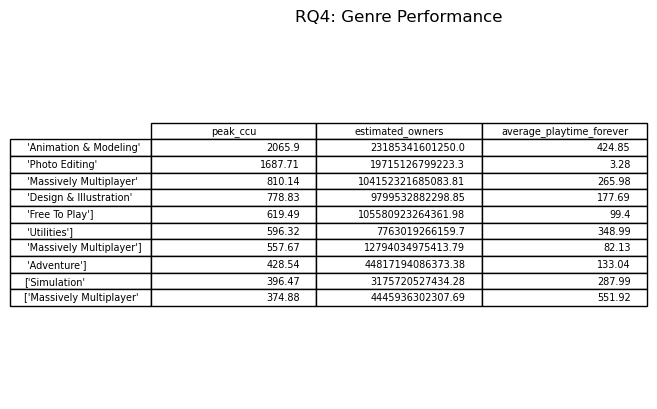

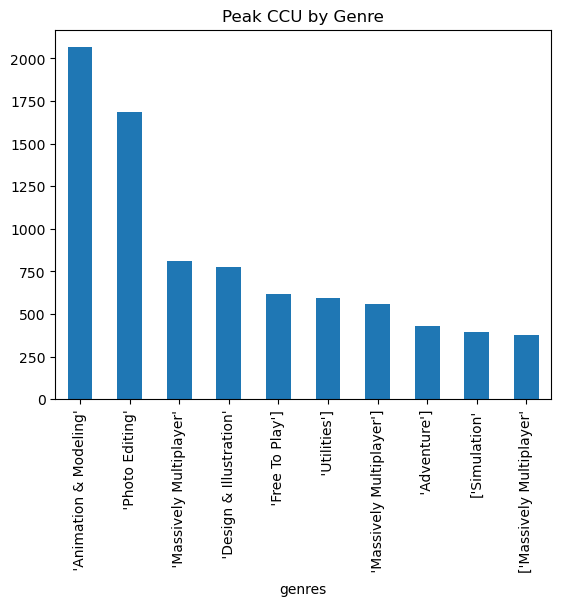

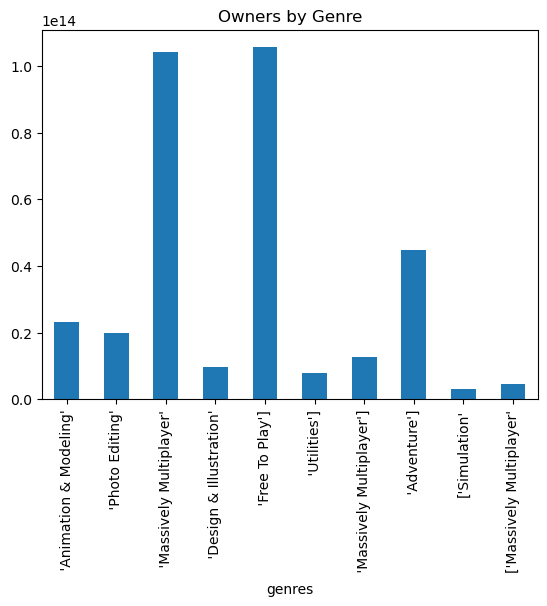

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('Tables', exist_ok=True)
os.makedirs('Models', exist_ok=True)

df = pd.read_csv(r'games_march2025_cleaned.csv')
df = df.drop_duplicates()

# CLEANING
df['peak_ccu'] = pd.to_numeric(df['peak_ccu'], errors='coerce')
df['average_playtime_forever'] = pd.to_numeric(df['average_playtime_forever'], errors='coerce')

df['estimated_owners'] = df['estimated_owners'].str.replace('[^0-9]', '', regex=True)
df['estimated_owners'] = pd.to_numeric(df['estimated_owners'], errors='coerce')

rq4 = df[['genres','peak_ccu','estimated_owners','average_playtime_forever']].dropna()

rq4['genres'] = rq4['genres'].str.split(',')
rq4 = rq4.explode('genres')

genre_group = rq4.groupby('genres').mean().sort_values('peak_ccu', ascending=False).head(10)

# TABLE
plt.figure()
plt.axis('off')
plt.table(cellText=np.round(genre_group.values,2),
          colLabels=genre_group.columns,
          rowLabels=genre_group.index,
          loc='center')
plt.title('RQ4: Genre Performance')
plt.savefig('Tables/RQ4_Table.png', dpi=300, bbox_inches='tight')
plt.show()

# FIGURES
plt.figure()
genre_group['peak_ccu'].plot(kind='bar')
plt.title('Peak CCU by Genre')
plt.savefig('Models/RQ4_Fig1.png', dpi=300)
plt.show()

plt.figure()
genre_group['estimated_owners'].plot(kind='bar')
plt.title('Owners by Genre')
plt.savefig('Models/RQ4_Fig2.png', dpi=300)
plt.show()
